# PreSense — 메인 실험 노트북

**Real-Time Presentation Stress Detection via Knowledge Distillation from Biosignals to Webcam and Microphone**

## 실험 구성
| 모델 | 입력 | 목적 |
|------|------|------|
| **Teacher** | Physio(132) + Video(84) + Audio(140) | 생리신호를 포함한 상한 성능 |
| **Student Baseline** | Video(84) + Audio(140) | KD 없이 Student 단독 성능 |
| **Student + KD** | Video(84) + Audio(140) | KD 적용 후 성능 향상 확인 |

## 아키텍처 구성

| 섹션 | 번호 | 이름 | 인코더 | KD 방식 | Feature KD | 상태 |
|------|------|------|--------|---------|------------|------|
| 2 | **①** | End-to-End (ResNet18 + Wav2Vec 2.0) | CNN+Transformer | Soft + Feature KD | ✅ | 구현만 (raw 데이터 필요) |
| 3 | **②** | Hybrid MLP Encoder | Linear × 2 + BN | Soft + Feature KD | ✅ | 실행 가능 |
| 4 | **③** | Handcrafted Feature + LSTM | Concat → LSTM | Soft Label KD only | ❌ | 실행 가능 |

```
Total Loss = α × KL_KD + β × Feature_KD + γ × CE
(Architecture ③은 β=0 자동 적용)
```

In [9]:
# 패키지 설치 (최초 1회)
# !pip install torch scikit-learn imbalanced-learn pandas numpy matplotlib seaborn

In [ ]:
import sys
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# presense 패키지 경로 추가
sys.path.insert(0, str(Path('.').resolve()))

import config
import sys
from pathlib import Path
for p in [".", "data", "models", "train", "evaluate", "analysis"]:
    if p not in sys.path: sys.path.insert(0, p)
from data.dataset  import load_all
from models   import build_models, load_checkpoint
from train    import train_teacher, train_student_baseline, train_student_kd
from evaluate import evaluate_model, compare_models, plot_training_history, plot_confusion_matrix, plot_kd_gain, predict

print(f'PyTorch: {torch.__version__}')
print(f'Device:  {torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu")}')

PyTorch: 2.12.0
Device:  mps


## 1. 공통 설정 & 데이터 로드

In [3]:
# ─── 실험 설정 ───────────────────────────────────────────────────────────────
TASK = '3class'    # 'binary' | '3class'
print("Task 설정 완료: ", TASK)

# ─── 데이터 로드 (Architecture ②③ 공통) ────────────────────────────────────
splits, teacher_loaders, student_loaders = load_all(task=TASK, fallback_labels=True)

t_train, t_val, t_test = teacher_loaders
s_train, s_val, s_test = student_loaders

col_idx = 4 if TASK == 'binary' else 5
print('\n레이블 분포 (train):', pd.Series(splits['train'][col_idx]).value_counts().to_dict())
print('레이블 분포 (test): ', pd.Series(splits['test'][col_idx]).value_counts().to_dict())

Task 설정 완료:  3class
[Physio]  shape: (773, 132)
[Video]   shape: (603, 84)
[Audio]   shape: (378, 140)
[Labels]  shape: (700, 2)  (from labels.csv)
[Align]   전체 샘플: 599  (audio 있음: 370)
[Split]   Train: 413  Val: 87  Test: 99
          Train subjects: 38  Test subjects: 9

레이블 분포 (train): {1: 284, 0: 79, 2: 50}
레이블 분포 (test):  {1: 58, 0: 25, 2: 16}


## 2. Architecture ① — End-to-End (ResNet18 + Wav2Vec 2.0)

Raw 영상 프레임 + Raw 음성 파형을 직접 처리 → Feature KD + Soft Label KD

| 항목 | 내용 |
|------|------|
| Teacher 입력 | Raw Video(T×3×224×224) + Raw Audio(16kHz) + Physio(3×T) |
| Student 입력 | Raw Video(T×3×224×224) + Raw Audio(16kHz) |
| 인코더 | ResNet18(f_v=512) + Wav2Vec2(f_a=256) + 1D-CNN(f_p=128, Teacher only) |
| KD | Soft Label KD + Feature KD |
| 구현 파일 | `models_e2e.py`, `dataset_e2e.py` |

> **현재 상태**: 코드 구현 완료, raw 영상/음성 데이터 준비 후 실행 예정

In [ ]:
RUN_E2E = False   # raw 영상/음성 데이터 준비 후 True로 변경

if RUN_E2E:
    import sys
    from pathlib import Path
    for p in [".", "data", "models", "train", "evaluate", "analysis"]:
        if p not in sys.path: sys.path.insert(0, p)
        from models.models_e2e import E2ETeacherModel, E2EStudentModel
        from data.dataset_e2e import StressIDRawDataset, build_sample_list

        # TODO: 1. labels_dict 준비
        #   labels_dict = {'subject_task': 0_or_1, ...}
        #   samples = build_sample_list(labels_dict)

        # TODO: 2. DataLoader 구성
        #   from torch.utils.data import DataLoader
        #   ds_teacher = StressIDRawDataset(samples, mode='teacher')
        #   ds_student = StressIDRawDataset(samples, mode='student')
        #   e2e_t_loader = DataLoader(ds_teacher, batch_size=4, shuffle=True)
        #   e2e_s_loader = DataLoader(ds_student, batch_size=4, shuffle=True)

        # TODO: 3. 별도 학습 루프 작성
        #   (raw 입력 처리 방식이 다르므로 train.py와 별개로 구성)
        print("Architecture ① E2E: raw 데이터 준비 후 실행하세요.")
        print("  → models_e2e.py  : E2ETeacherModel, E2EStudentModel")
        print("  → dataset_e2e.py : StressIDRawDataset, build_sample_list")

## 3. Architecture ② — Hybrid MLP Encoder

Handcrafted features(AU, MFCC, Physio) → modality별 MLP Encoder → Feature KD + Soft Label KD

| 항목 | 내용 |
|------|------|
| Teacher 입력 | Physio(132) + Video(84) + Audio(140) |
| Student 입력 | Video(84) + Audio(140) |
| 인코더 | Linear(dim→64) + BN + ReLU × 2 |
| KD | Soft Label KD + Feature KD (β > 0) |

### 3-1. 모델 빌드

In [4]:
t_mlp, s_mlp = build_models(arch='mlp', task=TASK)

### 3-2. Teacher 학습

In [5]:
history_t_mlp = train_teacher(
    t_mlp,
    train_loader=t_train,
    val_loader=t_val,
    arch='mlp',
    epochs=config.EPOCHS,
    save_path=str(config.CHECKPOINTS_DIR / 'teacher_mlp_best.pt'),
    verbose=True,
)
t_mlp = load_checkpoint(t_mlp, str(config.CHECKPOINTS_DIR / 'teacher_mlp_best.pt'))


[Teacher Train] device=mps  arch=mlp  epochs=100
  Epoch   1/100 | Train Loss 0.8531 Acc 0.6783 | Val Loss 0.7112 Acc 0.8084 | 0.7s
  Epoch  10/100 | Train Loss 0.1984 Acc 0.9269 | Val Loss 0.9832 Acc 0.6481 | 0.1s
  Early stopping at epoch 18.
[Teacher Train] Best Val Loss: 0.6397
[Checkpoint] Loaded from /Users/hanujin1/Desktop/HY/4-2/AI_Project/presense/checkpoints/teacher_mlp_best.pt


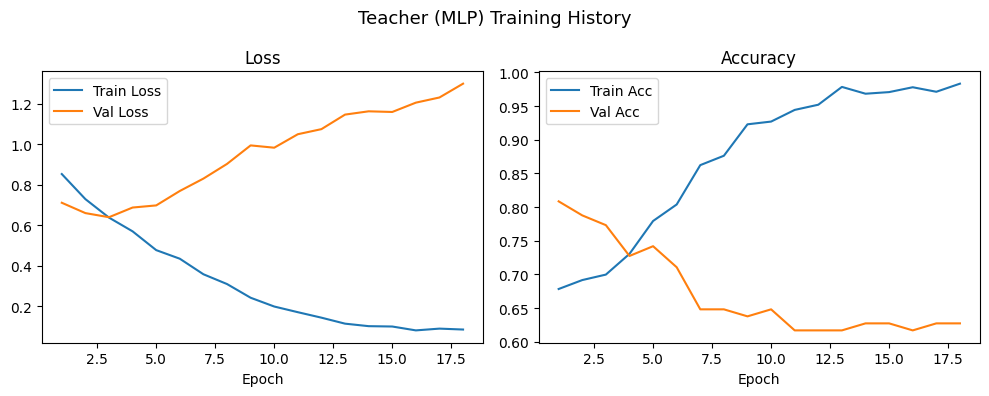

In [6]:
plot_training_history(history_t_mlp, title='Teacher (MLP) Training History',
                      save_path=str(config.RESULTS_DIR / TASK / 'Arch_2' / 'teacher_history.png'))

### 3-3. Student Baseline 학습 (KD 없음)

In [7]:
_, s_base_mlp = build_models(arch='mlp', task=TASK)

history_b_mlp = train_student_baseline(
    s_base_mlp,
    train_loader=s_train,
    val_loader=s_val,
    arch='mlp',
    epochs=config.EPOCHS,
    save_path=str(config.CHECKPOINTS_DIR / 'student_baseline_mlp_best.pt'),
    verbose=True,
)
s_base_mlp = load_checkpoint(s_base_mlp, str(config.CHECKPOINTS_DIR / 'student_baseline_mlp_best.pt'))


[Student Baseline] device=mps  arch=mlp  epochs=100
  Epoch   1/100 | Train Loss 0.8679 Acc 0.6716 | Val Loss 0.7860 Acc 0.8084
  Epoch  10/100 | Train Loss 0.3581 Acc 0.8423 | Val Loss 0.8747 Acc 0.5838
  Early stopping at epoch 17.
[Student Baseline] Best Val Loss: 0.7015
[Checkpoint] Loaded from /Users/hanujin1/Desktop/HY/4-2/AI_Project/presense/checkpoints/student_baseline_mlp_best.pt


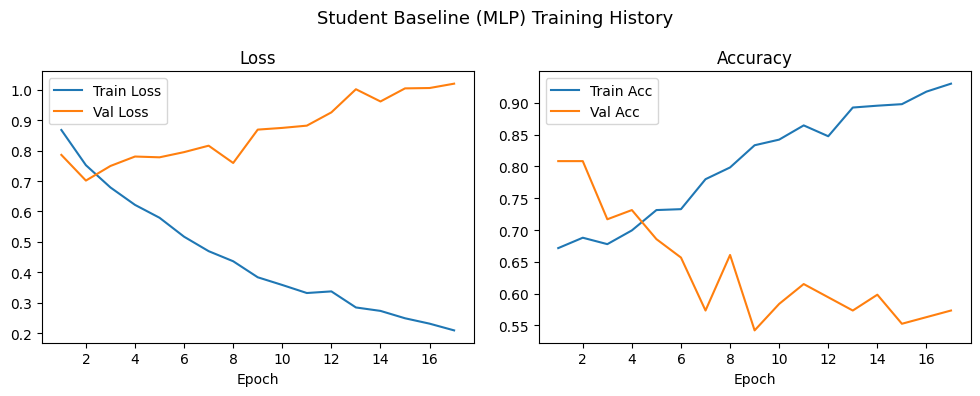

In [8]:
plot_training_history(history_b_mlp, title='Student Baseline (MLP) Training History',
                      save_path=str(config.RESULTS_DIR / TASK / 'Arch_2' / 'student_baseline_history.png'))

### 3-4. Student + KD 학습

In [9]:
_, s_kd_mlp = build_models(arch='mlp', task=TASK)

history_kd_mlp = train_student_kd(
    teacher=t_mlp,
    student=s_kd_mlp,
    train_loader=t_train,
    val_loader=s_val,
    arch='mlp',
    epochs=config.EPOCHS,
    alpha=config.KD_ALPHA,
    beta=config.KD_BETA,
    gamma=config.KD_GAMMA,
    temperature=config.KD_TEMPERATURE,
    save_path=str(config.CHECKPOINTS_DIR / 'student_kd_mlp_best.pt'),
    verbose=True,
)
s_kd_mlp = load_checkpoint(s_kd_mlp, str(config.CHECKPOINTS_DIR / 'student_kd_mlp_best.pt'))


[Student KD] device=mps  arch=mlp  epochs=100
             α=0.4  β=0.3  γ=0.3  T=4.0
  Epoch   1/100 | Total 0.6002 (SoftKD 0.3023 FeatKD 0.6942 CE 0.9034) | Val Acc 0.8084
  Epoch  10/100 | Total 0.2805 (SoftKD 0.0724 FeatKD 0.2981 CE 0.5404) | Val Acc 0.7192
  Epoch  20/100 | Total 0.2511 (SoftKD 0.0790 FeatKD 0.2403 CE 0.4915) | Val Acc 0.6775
  Early stopping at epoch 22.
[Student KD] Best Val Loss: 0.6931
[Checkpoint] Loaded from /Users/hanujin1/Desktop/HY/4-2/AI_Project/presense/checkpoints/student_kd_mlp_best.pt


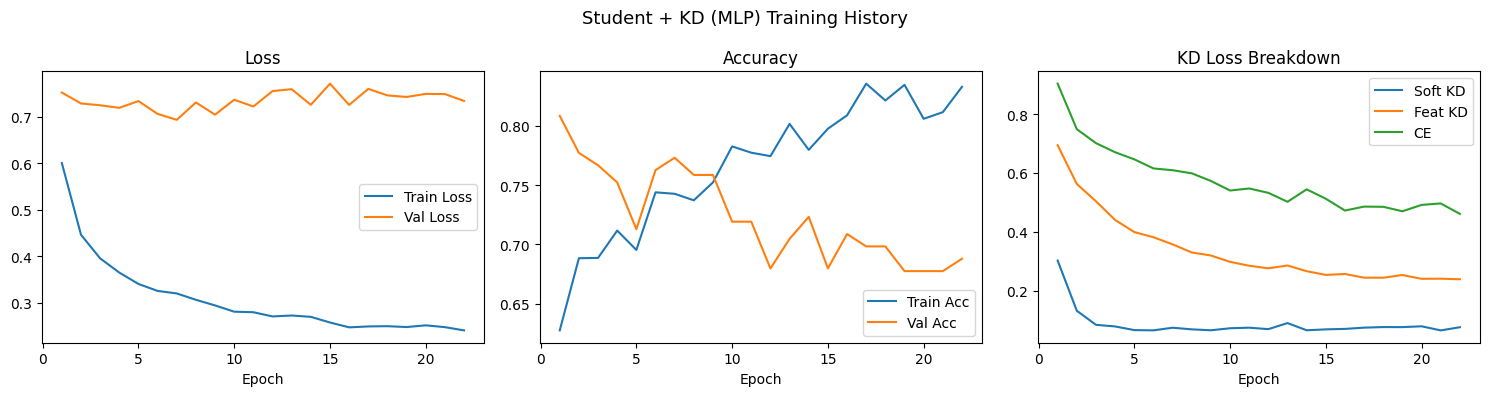

In [10]:
plot_training_history(history_kd_mlp, title='Student + KD (MLP) Training History',
                      save_path=str(config.RESULTS_DIR / TASK / 'Arch_2' / 'student_kd_history.png'))

### 3-5. 성능 비교 (Test Set)

In [11]:
results_mlp = {}

results_mlp['Teacher'] = evaluate_model(
    t_mlp, t_test, arch='mlp', mode='teacher', task=TASK, label='Teacher (MLP)')

results_mlp['Student Baseline'] = evaluate_model(
    s_base_mlp, s_test, arch='mlp', mode='student', task=TASK, label='Student Baseline (MLP)')

results_mlp['Student + KD'] = evaluate_model(
    s_kd_mlp, s_test, arch='mlp', mode='student', task=TASK, label='Student + KD (MLP)')

df_mlp = compare_models(results_mlp, task=TASK)
df_mlp.to_csv(config.RESULTS_DIR / TASK / 'Arch_2' / 'comparison.csv')



  Teacher (MLP)
  Accuracy:          0.5657
  Balanced Accuracy: 0.3218
  F1 (weighted):     0.4233
  F1 (macro):        0.2409

              precision    recall  f1-score   support

     Relaxed       0.00      0.00      0.00        25
     Neutral       0.58      0.97      0.72        58
    Stressed       0.00      0.00      0.00        16

    accuracy                           0.57        99
   macro avg       0.19      0.32      0.24        99
weighted avg       0.34      0.57      0.42        99


  Student Baseline (MLP)
  Accuracy:          0.5859
  Balanced Accuracy: 0.3333
  F1 (weighted):     0.4329
  F1 (macro):        0.2463

              precision    recall  f1-score   support

     Relaxed       0.00      0.00      0.00        25
     Neutral       0.59      1.00      0.74        58
    Stressed       0.00      0.00      0.00        16

    accuracy                           0.59        99
   macro avg       0.20      0.33      0.25        99
weighted avg       0.34 

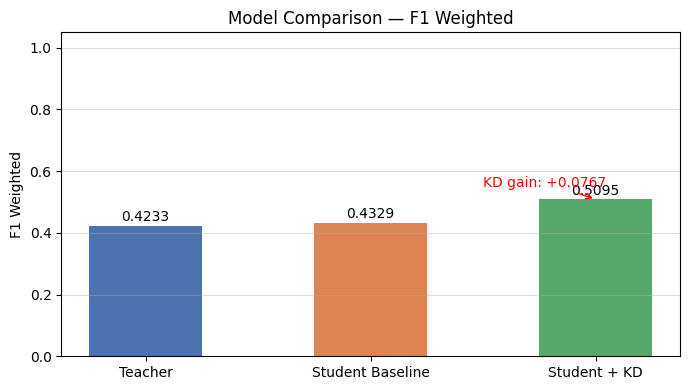

In [12]:
plot_kd_gain(results_mlp, metric='f1_weighted',
             save_path=str(config.RESULTS_DIR / TASK / 'Arch_2' / 'kd_gain.png'))

### 3-6. Confusion Matrix

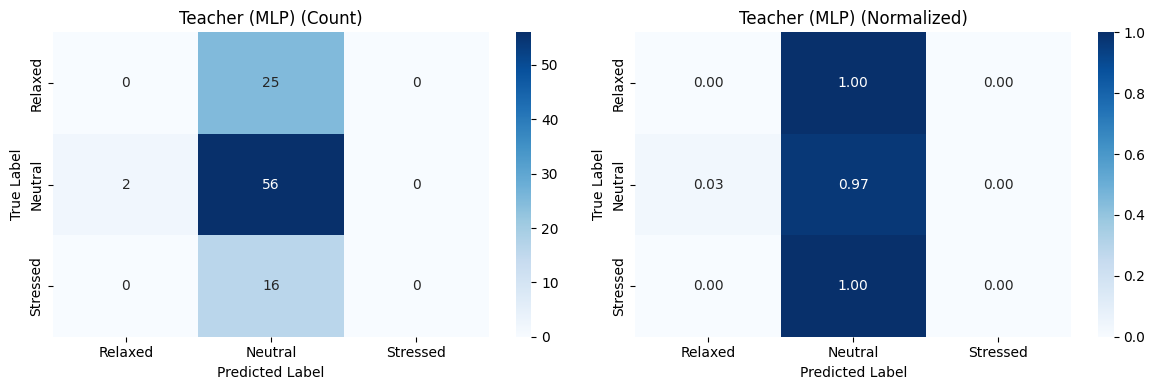

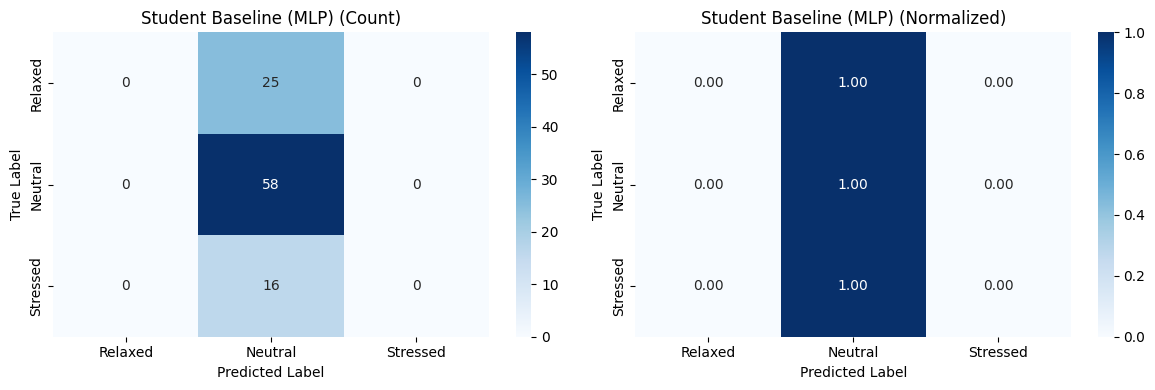

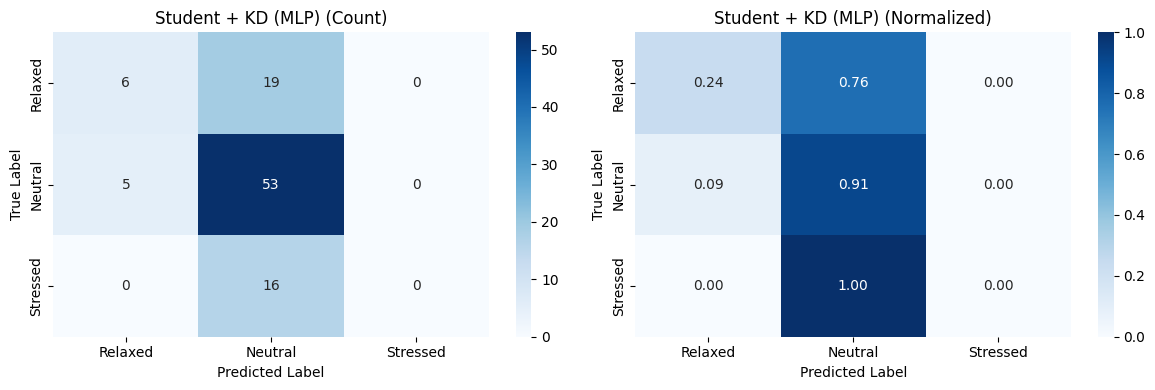

In [13]:
for name, model, loader, mode in [
    ('Teacher (MLP)',          t_mlp,      t_test, 'teacher'),
    ('Student Baseline (MLP)', s_base_mlp, s_test, 'student'),
    ('Student + KD (MLP)',     s_kd_mlp,   s_test, 'student'),
]:
    y_true, y_pred, _ = predict(model, loader, arch='mlp', mode=mode)
    # 결과 폴더 생성
    save_dir = config.RESULTS_DIR / TASK / 'Arch_2'
    save_dir.mkdir(parents=True, exist_ok=True)
    
    plot_confusion_matrix(
        y_true, y_pred,
        task=TASK,
        title=name,
        save_path=str(save_dir / f'cm_{name.lower().split(" ")[0]}.png')
    )

## 4. Architecture ③ — Handcrafted Feature + LSTM

Handcrafted features(AU, MFCC, Physio) → Concat → LSTM → Soft Label KD only

| 항목 | 내용 |
|------|------|
| Teacher 입력 | Physio(132) + Video(84) + Audio(140) → Concat(356) → LSTM |
| Student 입력 | Video(84) + Audio(140) → Concat(224) → LSTM |
| 인코더 | LSTM(hidden=128, layers=2) |
| KD | Soft Label KD only (β=0, Feature KD 미사용) |

### 4-1. 모델 빌드

In [14]:
t_lstm, s_lstm = build_models(arch='lstm', task=TASK)

### 4-2. Teacher 학습

In [15]:
history_t_lstm = train_teacher(
    t_lstm,
    train_loader=t_train,
    val_loader=t_val,
    arch='lstm',
    epochs=config.EPOCHS,
    save_path=str(config.CHECKPOINTS_DIR / 'teacher_lstm_best.pt'),
    verbose=True,
)
t_lstm = load_checkpoint(t_lstm, str(config.CHECKPOINTS_DIR / 'teacher_lstm_best.pt'))


[Teacher Train] device=mps  arch=lstm  epochs=100
  Epoch   1/100 | Train Loss 1.0483 Acc 0.5002 | Val Loss 0.9778 Acc 0.7088 | 0.3s
  Epoch  10/100 | Train Loss 0.0345 Acc 0.9952 | Val Loss 1.1603 Acc 0.7147 | 0.3s
  Early stopping at epoch 18.
[Teacher Train] Best Val Loss: 0.6758
[Checkpoint] Loaded from /Users/hanujin1/Desktop/HY/4-2/AI_Project/presense/checkpoints/teacher_lstm_best.pt


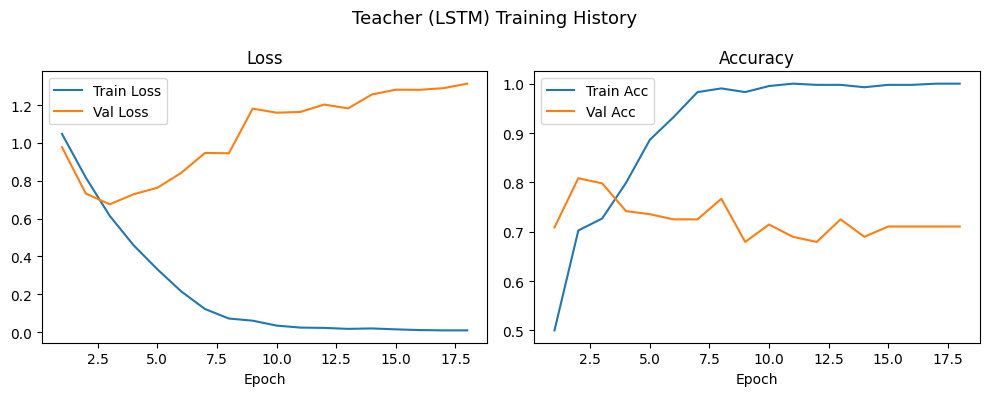

In [16]:
plot_training_history(history_t_lstm, title='Teacher (LSTM) Training History',
                      save_path=str(config.RESULTS_DIR / TASK / 'Arch_3' / 'teacher_history.png'))

### 4-3. Student Baseline 학습 (KD 없음)

In [17]:
_, s_base_lstm = build_models(arch='lstm', task=TASK)

history_b_lstm = train_student_baseline(
    s_base_lstm,
    train_loader=s_train,
    val_loader=s_val,
    arch='lstm',
    epochs=config.EPOCHS,
    save_path=str(config.CHECKPOINTS_DIR / 'student_baseline_lstm_best.pt'),
    verbose=True,
)
s_base_lstm = load_checkpoint(s_base_lstm, str(config.CHECKPOINTS_DIR / 'student_baseline_lstm_best.pt'))


[Student Baseline] device=mps  arch=lstm  epochs=100
  Epoch   1/100 | Train Loss 1.0610 Acc 0.4925 | Val Loss 0.9556 Acc 0.8084
  Epoch  10/100 | Train Loss 0.2183 Acc 0.9226 | Val Loss 1.0531 Acc 0.6649
  Early stopping at epoch 17.
[Student Baseline] Best Val Loss: 0.6883
[Checkpoint] Loaded from /Users/hanujin1/Desktop/HY/4-2/AI_Project/presense/checkpoints/student_baseline_lstm_best.pt


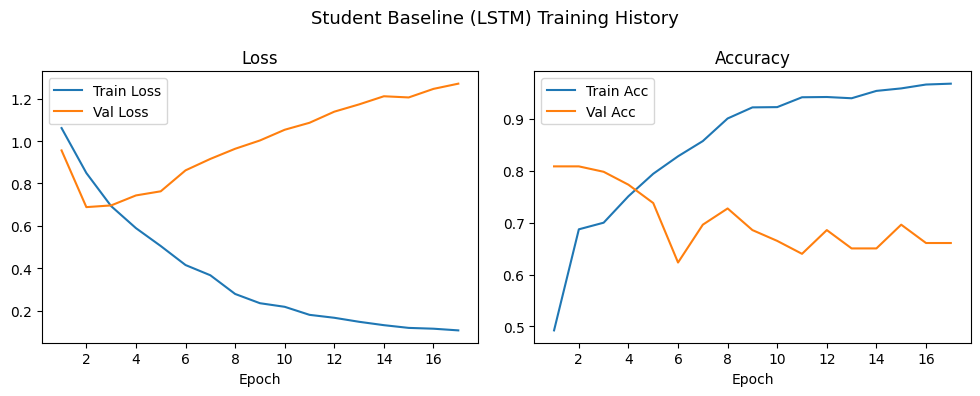

In [18]:
plot_training_history(history_b_lstm, title='Student Baseline (LSTM) Training History',
                      save_path=str(config.RESULTS_DIR / TASK / 'Arch_3' / 'student_baseline_history.png'))

### 4-4. Student + KD 학습

In [19]:
_, s_kd_lstm = build_models(arch='lstm', task=TASK)

history_kd_lstm = train_student_kd(
    teacher=t_lstm,
    student=s_kd_lstm,
    train_loader=t_train,
    val_loader=s_val,
    arch='lstm',
    epochs=config.EPOCHS,
    alpha=config.KD_ALPHA,
    beta=0.0,                      # LSTM: Feature KD 미사용 (β=0)
    gamma=config.KD_GAMMA,
    temperature=config.KD_TEMPERATURE,
    save_path=str(config.CHECKPOINTS_DIR / 'student_kd_lstm_best.pt'),
    verbose=True,
)
s_kd_lstm = load_checkpoint(s_kd_lstm, str(config.CHECKPOINTS_DIR / 'student_kd_lstm_best.pt'))


[Student KD] device=mps  arch=lstm  epochs=100
             α=0.4  β=0.0  γ=0.3  T=4.0
  Epoch   1/100 | Total 0.8038 (SoftKD 0.6356 FeatKD 0.0000 CE 1.0280) | Val Acc 0.8188
  Epoch  10/100 | Total 0.2152 (SoftKD 0.0584 FeatKD 0.0000 CE 0.4243) | Val Acc 0.7523
  Early stopping at epoch 17.
[Student KD] Best Val Loss: 0.6388
[Checkpoint] Loaded from /Users/hanujin1/Desktop/HY/4-2/AI_Project/presense/checkpoints/student_kd_lstm_best.pt


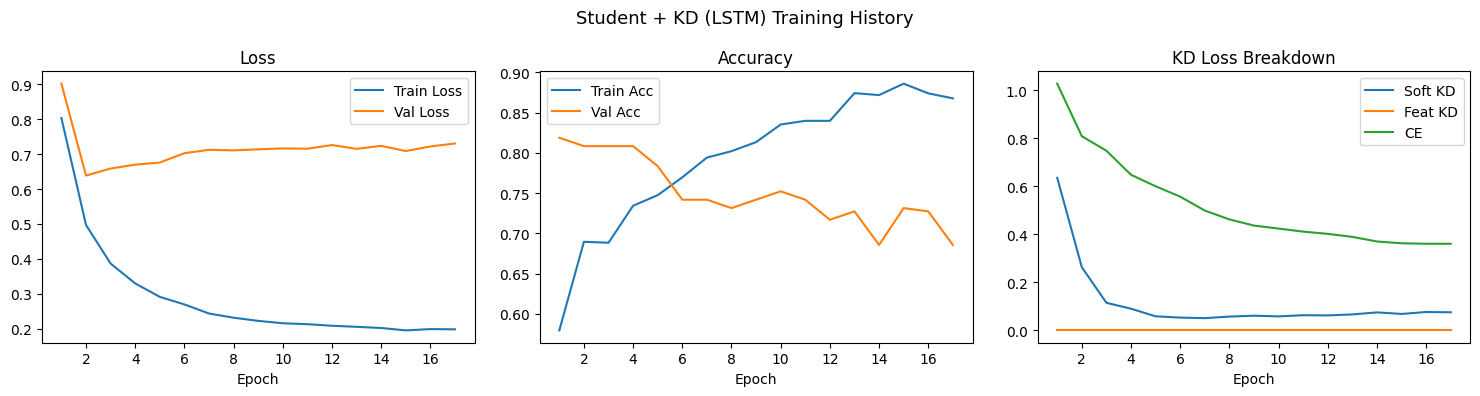

In [20]:
plot_training_history(history_kd_lstm, title='Student + KD (LSTM) Training History',
                      save_path=str(config.RESULTS_DIR / TASK / 'Arch_3' / 'student_kd_history.png'))

### 4-5. 성능 비교 (Test Set)

In [21]:
results_lstm = {}

results_lstm['Teacher'] = evaluate_model(
    t_lstm, t_test, arch='lstm', mode='teacher', task=TASK, label='Teacher (LSTM)')

results_lstm['Student Baseline'] = evaluate_model(
    s_base_lstm, s_test, arch='lstm', mode='student', task=TASK, label='Student Baseline (LSTM)')

results_lstm['Student + KD'] = evaluate_model(
    s_kd_lstm, s_test, arch='lstm', mode='student', task=TASK, label='Student + KD (LSTM)')

df_lstm = compare_models(results_lstm, task=TASK)
df_lstm.to_csv(config.RESULTS_DIR / TASK / 'Arch_3' / 'comparison.csv')



  Teacher (LSTM)
  Accuracy:          0.5859
  Balanced Accuracy: 0.3409
  F1 (weighted):     0.4524
  F1 (macro):        0.2714

              precision    recall  f1-score   support

     Relaxed       0.50      0.04      0.07        25
     Neutral       0.59      0.98      0.74        58
    Stressed       0.00      0.00      0.00        16

    accuracy                           0.59        99
   macro avg       0.36      0.34      0.27        99
weighted avg       0.47      0.59      0.45        99


  Student Baseline (LSTM)
  Accuracy:          0.5859
  Balanced Accuracy: 0.3333
  F1 (weighted):     0.4329
  F1 (macro):        0.2463

              precision    recall  f1-score   support

     Relaxed       0.00      0.00      0.00        25
     Neutral       0.59      1.00      0.74        58
    Stressed       0.00      0.00      0.00        16

    accuracy                           0.59        99
   macro avg       0.20      0.33      0.25        99
weighted avg       0.3

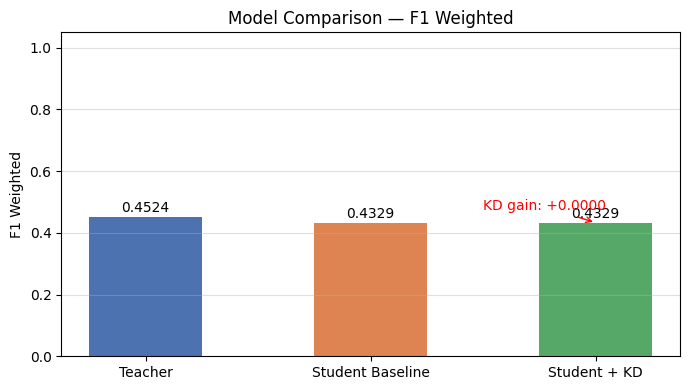

In [22]:
plot_kd_gain(results_lstm, metric='f1_weighted',
             save_path=str(config.RESULTS_DIR / TASK / 'Arch_3' / 'kd_gain.png'))

### 4-6. Confusion Matrix

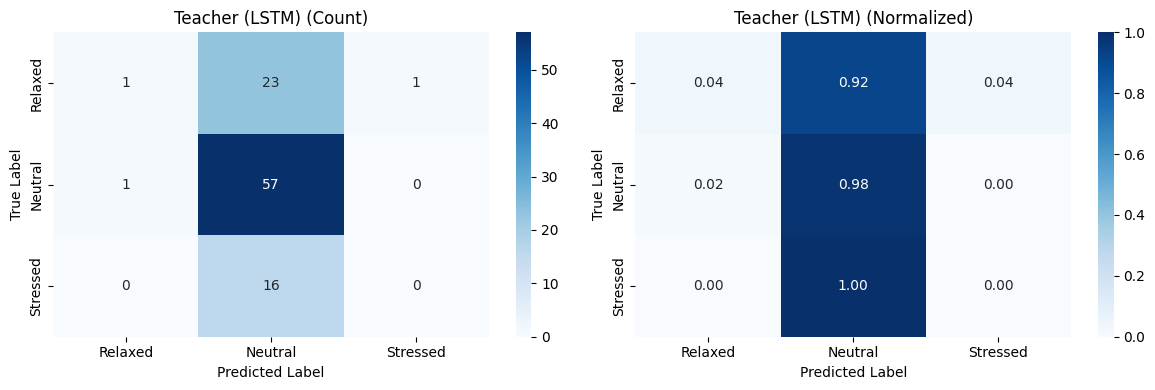

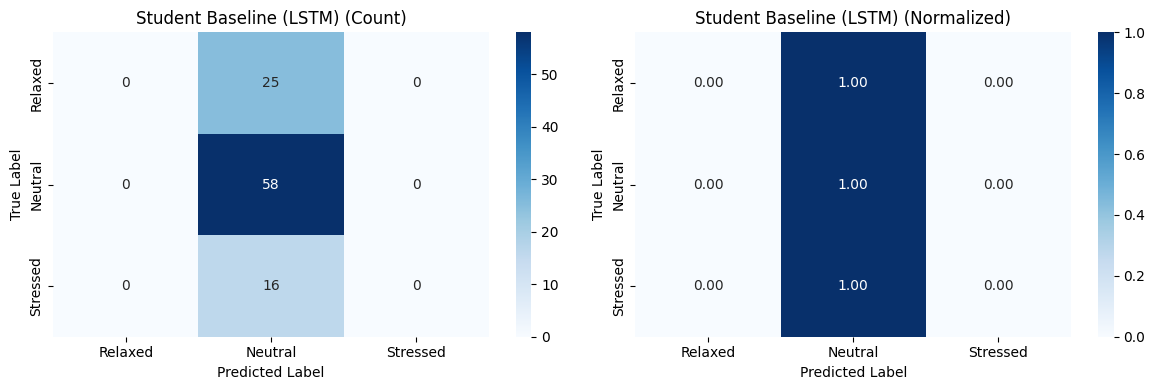

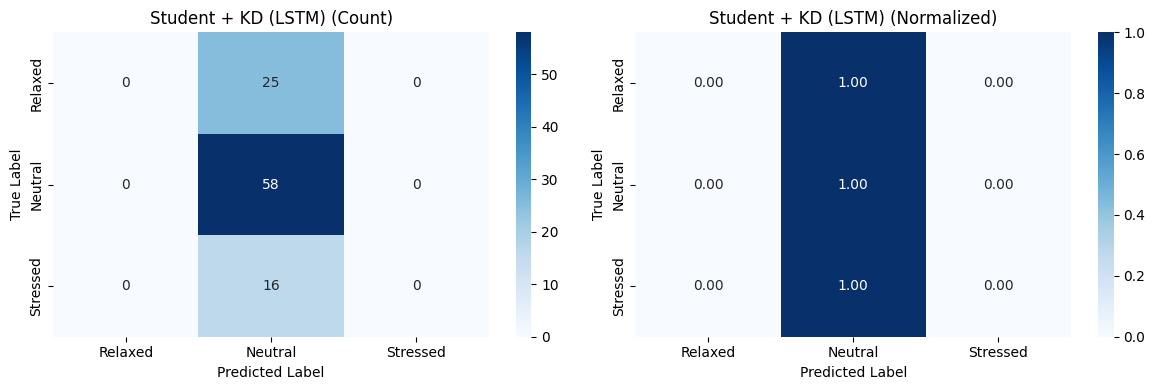

In [23]:
for name, model, loader, mode in [
    ('Teacher (LSTM)',          t_lstm,      t_test, 'teacher'),
    ('Student Baseline (LSTM)', s_base_lstm, s_test, 'student'),
    ('Student + KD (LSTM)',     s_kd_lstm,   s_test, 'student'),
]:
    y_true, y_pred, _ = predict(model, loader, arch='lstm', mode=mode)
    # 결과 폴더 생성
    save_dir = config.RESULTS_DIR / TASK / 'Arch_3'
    save_dir.mkdir(parents=True, exist_ok=True)
    
    plot_confusion_matrix(
        y_true, y_pred,
        task=TASK,
        title=name,
        save_path=str(save_dir / f'cm_{name.lower().split(" ")[0]}.png')
    )

## 5. KD 하이퍼파라미터 탐색 (선택)

> α, β, γ 최적 조합 탐색 — Architecture ②(mlp) 기준으로 실행

In [23]:
SEARCH = False   # True로 변경 시 탐색 실행 (시간 소요)

if SEARCH:
    grid = [
        (0.5, 0.3, 0.2),
        (0.4, 0.3, 0.3),
        (0.3, 0.4, 0.3),
        (0.6, 0.2, 0.2),
    ]
    search_results = []

    for alpha, beta, gamma in grid:
        print(f'\n--- α={alpha} β={beta} γ={gamma} ---')
        _, s = build_models(arch='mlp', task=TASK)
        train_student_kd(
            t_mlp, s, t_train, s_val,
            arch='mlp', epochs=50,
            alpha=alpha, beta=beta, gamma=gamma,
            save_path=str(config.CHECKPOINTS_DIR / f'student_kd_{alpha}_{beta}_{gamma}.pt'),
            verbose=False,
        )
        s = load_checkpoint(s, str(config.CHECKPOINTS_DIR / f'student_kd_{alpha}_{beta}_{gamma}.pt'))
        m = evaluate_model(s, s_test, arch='mlp', mode='student', task=TASK, verbose=False)
        search_results.append({'alpha': alpha, 'beta': beta, 'gamma': gamma, **m})

    df_search = pd.DataFrame(search_results)
    print(df_search.sort_values('f1_weighted', ascending=False))
    df_search.to_csv(config.RESULTS_DIR / 'kd_hparam_search.csv', index=False)

## 6. 3-Class 분류 실험 (선택)

In [25]:
RUN_3CLASS = True   # True로 변경 시 3-class 실험 실행

if RUN_3CLASS:
    splits3, tl3, sl3 = load_all(task='3class', fallback_labels=True)
    t3_train, t3_val, t3_test = tl3
    s3_train, s3_val, s3_test = sl3

    teacher3, _ = build_models(arch='mlp', task='3class')

    train_teacher(teacher3, t3_train, t3_val, arch='mlp',
                  save_path=str(config.CHECKPOINTS_DIR / 'teacher3_mlp_best.pt'))
    teacher3 = load_checkpoint(teacher3, str(config.CHECKPOINTS_DIR / 'teacher3_mlp_best.pt'))

    _, student3_kd = build_models(arch='mlp', task='3class')
    train_student_kd(teacher3, student3_kd, t3_train, s3_val,
                     arch='mlp',
                     save_path=str(config.CHECKPOINTS_DIR / 'student3_kd_mlp_best.pt'))
    student3_kd = load_checkpoint(student3_kd, str(config.CHECKPOINTS_DIR / 'student3_kd_mlp_best.pt'))

    results3 = {}
    results3['Teacher']      = evaluate_model(teacher3,    t3_test, arch='mlp', mode='teacher',
                                              task='3class', label='Teacher (3-class MLP)')
    results3['Student + KD'] = evaluate_model(student3_kd, s3_test, arch='mlp', mode='student',
                                              task='3class', label='Student+KD (3-class MLP)')
    compare_models(results3, task='3class')

[Physio]  shape: (773, 132)
[Video]   shape: (603, 84)
[Audio]   shape: (378, 140)
[Labels]  shape: (700, 2)  (from labels.csv)
[Align]   전체 샘플: 599  (audio 있음: 370)
[Split]   Train: 413  Val: 87  Test: 99
          Train subjects: 38  Test subjects: 9
[Model]   arch=mlp  |  Teacher params: 96,963  |  Student params: 63,107

[Teacher Train] device=mps  arch=mlp  epochs=100
  Epoch   1/100 | Train Loss 0.9362 Acc 0.5821 | Val Loss 0.6877 Acc 0.8084 | 0.2s
  Epoch  10/100 | Train Loss 0.2193 Acc 0.9178 | Val Loss 0.9438 Acc 0.6793 | 0.2s
  Early stopping at epoch 18.
[Teacher Train] Best Val Loss: 0.6338
[Checkpoint] Loaded from /Users/hanujin1/Desktop/HY/4-2/AI_Project/presense/checkpoints/teacher3_mlp_best.pt  (epoch 3)
[Model]   arch=mlp  |  Teacher params: 96,963  |  Student params: 63,107

[Student KD] device=mps  arch=mlp  epochs=100
             α=0.4  β=0.3  γ=0.3  T=4.0
  Epoch   1/100 | Total 0.5946 (SoftKD 0.3079 FeatKD 0.6484 CE 0.9230) | Val Acc 0.8084
  Epoch  10/100 | Tota

## 7. 아키텍처 비교 (Architecture ② vs ③)

두 아키텍처를 동일 데이터로 학습해 KD 효과를 비교합니다.

| arch | Architecture | 인코더 | Feature KD |
|------|-------------|--------|------------|
| `'mlp'`  | ② Hybrid MLP Encoder | Linear × 2 + BN | ✅ |
| `'lstm'` | ③ Handcrafted + LSTM | Concat → LSTM | ❌ |

> Architecture ① (E2E ResNet18 + Wav2Vec2)은 raw 영상/음성 데이터 준비 후 `models_e2e.py`로 별도 실행


  Architecture: MLP
[Model]   arch=mlp  |  Teacher params: 96,963  |  Student params: 63,107

[Teacher Train] device=mps  arch=mlp  epochs=100
  Early stopping at epoch 18.
[Teacher Train] Best Val Loss: 0.6359
[Checkpoint] Loaded from /Users/hanujin1/Desktop/HY/4-2/AI_Project/presense/checkpoints/teacher_mlp.pt  (epoch 3)
[Model]   arch=mlp  |  Teacher params: 96,963  |  Student params: 63,107

[Student Baseline] device=mps  arch=mlp  epochs=100
  Early stopping at epoch 17.
[Student Baseline] Best Val Loss: 0.6991
[Checkpoint] Loaded from /Users/hanujin1/Desktop/HY/4-2/AI_Project/presense/checkpoints/student_base_mlp.pt  (epoch 2)
[Model]   arch=mlp  |  Teacher params: 96,963  |  Student params: 63,107

[Student KD] device=mps  arch=mlp  epochs=100
             α=0.4  β=0.3  γ=0.3  T=4.0
  Early stopping at epoch 21.
[Student KD] Best Val Loss: 0.7053
[Checkpoint] Loaded from /Users/hanujin1/Desktop/HY/4-2/AI_Project/presense/checkpoints/student_kd_mlp.pt  (epoch 6)

  Architecture:

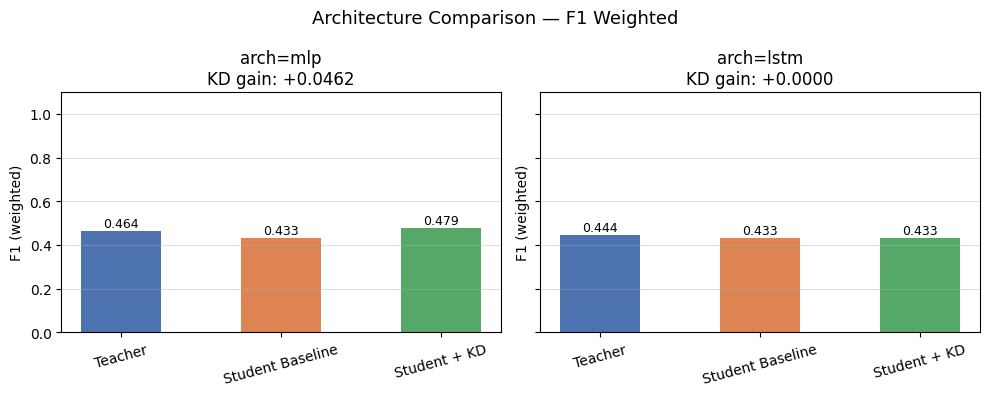

In [27]:
RUN_ARCH_COMPARISON = True   # True로 변경 시 2개 아키텍처 비교 실행 (시간 소요)

if RUN_ARCH_COMPARISON:
    arch_results = {}          # {arch: {'Teacher': m, 'Student Baseline': m, 'Student + KD': m}}

    for arch_name in ('mlp', 'lstm'):
        print(f"\n{'='*60}")
        print(f"  Architecture: {arch_name.upper()}")
        print(f"{'='*60}")

        ckpt = lambda tag: str(config.CHECKPOINTS_DIR / f'{tag}_{arch_name}.pt')

        # Teacher 학습
        t, s = build_models(arch=arch_name, task=TASK)
        train_teacher(t, t_train, t_val, arch=arch_name,
                      save_path=ckpt('teacher'), verbose=False)
        t = load_checkpoint(t, ckpt('teacher'))

        # Student Baseline
        _, s_base = build_models(arch=arch_name, task=TASK)
        train_student_baseline(s_base, s_train, s_val, arch=arch_name,
                               save_path=ckpt('student_base'), verbose=False)
        s_base = load_checkpoint(s_base, ckpt('student_base'))

        # Student + KD
        _, s_kd = build_models(arch=arch_name, task=TASK)
        train_student_kd(t, s_kd, t_train, s_val, arch=arch_name,
                         save_path=ckpt('student_kd'), verbose=False)
        s_kd = load_checkpoint(s_kd, ckpt('student_kd'))

        # 평가
        arch_results[arch_name] = {
            'Teacher':          evaluate_model(t,      t_test, arch=arch_name, mode='teacher',
                                               task=TASK, label=f'Teacher ({arch_name})',      verbose=False),
            'Student Baseline': evaluate_model(s_base, s_test, arch=arch_name, mode='student',
                                               task=TASK, label=f'Baseline ({arch_name})',     verbose=False),
            'Student + KD':     evaluate_model(s_kd,   s_test, arch=arch_name, mode='student',
                                               task=TASK, label=f'Student+KD ({arch_name})',   verbose=False),
        }

    # ─── 아키텍처 × 모델 비교표 ──────────────────────────────────────────────
    rows = []
    for arch_name, res in arch_results.items():
        for model_name, m in res.items():
            rows.append({
                'Architecture': arch_name,
                'Model':        model_name,
                'Accuracy':     f"{m['accuracy']:.4f}",
                'Balanced Acc': f"{m['balanced_accuracy']:.4f}",
                'F1 (weighted)':f"{m['f1_weighted']:.4f}",
                'F1 (macro)':   f"{m['f1_macro']:.4f}",
            })
    df_arch = pd.DataFrame(rows).set_index(['Architecture', 'Model'])
    print("\n" + "="*70)
    print("  Architecture Comparison")
    print("="*70)
    print(df_arch.to_string())
    # 결과 저장
    save_dir = config.RESULTS_DIR / TASK
    save_dir.mkdir(parents=True, exist_ok=True)
    df_arch.to_csv(save_dir / 'arch_comparison.csv')

    # ─── KD Gain 비교 막대 그래프 ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, len(arch_results), figsize=(5 * len(arch_results), 4),
                             sharey=True)
    colors = {'Teacher': '#4C72B0', 'Student Baseline': '#DD8452', 'Student + KD': '#55A868'}

    for ax, (arch_name, res) in zip(axes, arch_results.items()):
        names  = list(res.keys())
        values = [res[n]['f1_weighted'] for n in names]
        bars   = ax.bar(names, values,
                        color=[colors[n] for n in names], width=0.5)
        for bar, v in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9)
        gain = res['Student + KD']['f1_weighted'] - res['Student Baseline']['f1_weighted']
        ax.set_title(f'arch={arch_name}\nKD gain: {gain:+.4f}')
        ax.set_ylim(0, 1.1)
        ax.set_ylabel('F1 (weighted)')
        ax.tick_params(axis='x', rotation=15)
        ax.grid(axis='y', alpha=0.4)

    fig.suptitle('Architecture Comparison — F1 Weighted', fontsize=13)
    plt.tight_layout()
    plt.savefig(save_dir / 'arch_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()